In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Direct download link format
file_id = "1JiN8Emi8qPL5Ok-Db_mpNObCEla6mrDZ"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

# Check
df.head()


,Age,Income,Education_Years,Experience_Years,Spending_Score,Savings,Credit_Score,Debt,Hours_Online,Purchases_Month,...,Discount_Usage,Mobile_App_Usage,Transactions_Value,Fraud_Risk_Score,Loyalty_Points,Dropout_Probability,Market_Segment,Region_Code,Channel _ Preference,Risk_Class
0,56,25903.30520,12,13,63,19560.15085,684,15031.51868,10,5,...,0.4117,3,2960,0.3414,691,0.4234,5,1,2,1
1,69,53051.95454,17,26,22,16273.42337,732,21472.02455,3,6,...,0.9118,2,3578,0.1626,6066,0.6871,1,3,1,1
2,46,38654.73882,11,28,70,11729.48424,630,3447.25069,10,4,...,0.1642,4,3585,0.4752,8448,0.6225,1,5,3,1
3,32,28666.19436,11,38,21,20099.81639,709,10506.40384,0,9,...,0.2485,9,2232,0.2598,3432,0.4457,2,6,2,0
4,60,40301.40674,11,38,96,16293.42108,735,9128.02300,11,4,...,0.6062,5,3087,0.0522,833,0.3019,5,3,3,0


# **1(a)(i) Income vs Spending_Score scatter**

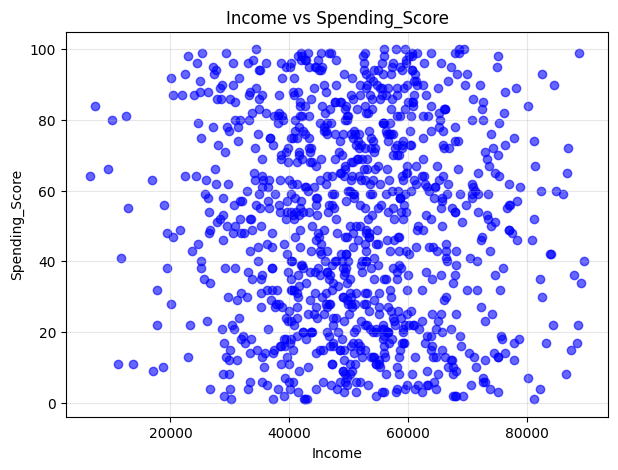

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(df["Income"], df["Spending_Score"], alpha=0.6, color="blue")
plt.xlabel("Income")
plt.ylabel("Spending_Score")
plt.title("Income vs Spending_Score")
plt.grid(True, alpha=0.3)
plt.show()


# **1(a)(ii) Income vs Spending_Score colored by Risk_Class**

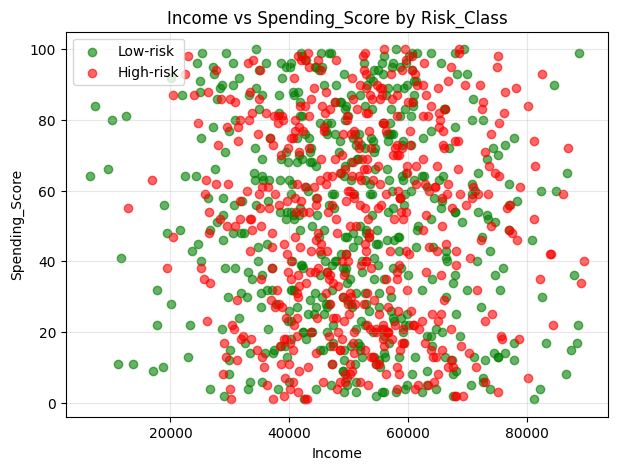

In [19]:
plt.figure(figsize=(7,5))

low = df[df["Risk_Class"] == 0]
high = df[df["Risk_Class"] == 1]

plt.scatter(low["Income"], low["Spending_Score"], alpha=0.6, label="Low-risk", color="green")
plt.scatter(high["Income"], high["Spending_Score"], alpha=0.6, label="High-risk", color="red")

plt.xlabel("Income")
plt.ylabel("Spending_Score")
plt.title("Income vs Spending_Score by Risk_Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# **1(b)(i) Distribution of Credit_Score**

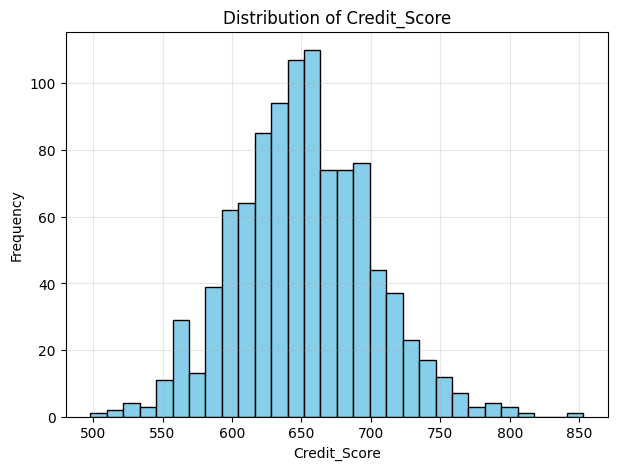

In [20]:
plt.figure(figsize=(7,5))
plt.hist(df["Credit_Score"], bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Credit_Score")
plt.ylabel("Frequency")
plt.title("Distribution of Credit_Score")
plt.grid(True, alpha=0.3)
plt.show()


# **1(b)(ii) Transactions_Value across Market_Segment**

/tmp/ipython-input-557933638.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=segments)


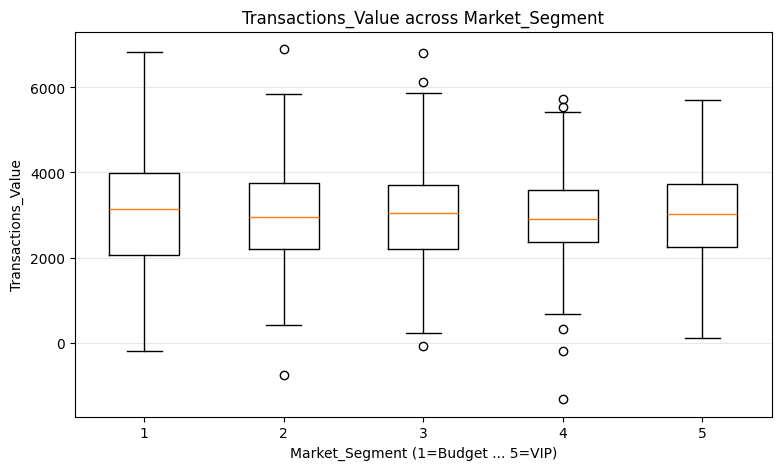

In [21]:
df["Market_Segment"] = df["Market_Segment"].astype("category")

segments = sorted(df["Market_Segment"].cat.categories)
data = [df[df["Market_Segment"] == s]["Transactions_Value"] for s in segments]

plt.figure(figsize=(9,5))
plt.boxplot(data, labels=segments)
plt.xlabel("Market_Segment (1=Budget ... 5=VIP)")
plt.ylabel("Transactions_Value")
plt.title("Transactions_Value across Market_Segment")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# **1(c) Correlation Heatmap (10 important numeric variables)**

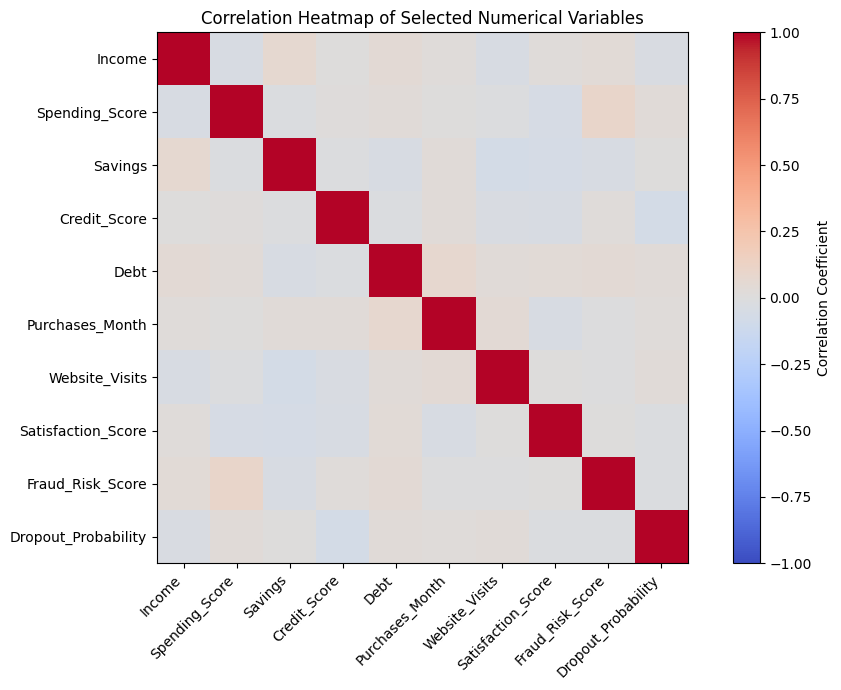

Top strong correlations:
Spending_Score  Fraud_Risk_Score       0.100118
Debt            Purchases_Month        0.071782
Credit_Score    Dropout_Probability   -0.068613
Income          Savings                0.068606
Savings         Website_Visits        -0.063316
                Satisfaction_Score    -0.056630
dtype: float64


In [22]:
vars10 = [
    "Income",
    "Spending_Score",
    "Savings",
    "Credit_Score",
    "Debt",
    "Purchases_Month",
    "Website_Visits",
    "Satisfaction_Score",
    "Fraud_Risk_Score",
    "Dropout_Probability"
]

# ===== Correlation matrix =====
corr = df[vars10].corr()

# ===== Plot correlation heatmap =====
plt.figure(figsize=(10,7))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")
plt.xticks(range(len(vars10)), vars10, rotation=45, ha="right")
plt.yticks(range(len(vars10)), vars10)
plt.title("Correlation Heatmap of Selected Numerical Variables")
plt.tight_layout()
plt.show()

# ===== Identify strongest correlations =====
upper_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_corr = upper_corr.stack().reindex(
    upper_corr.stack().abs().sort_values(ascending=False).index
)

print("Top strong correlations:")
print(strong_corr.head(6))

**Question 2**

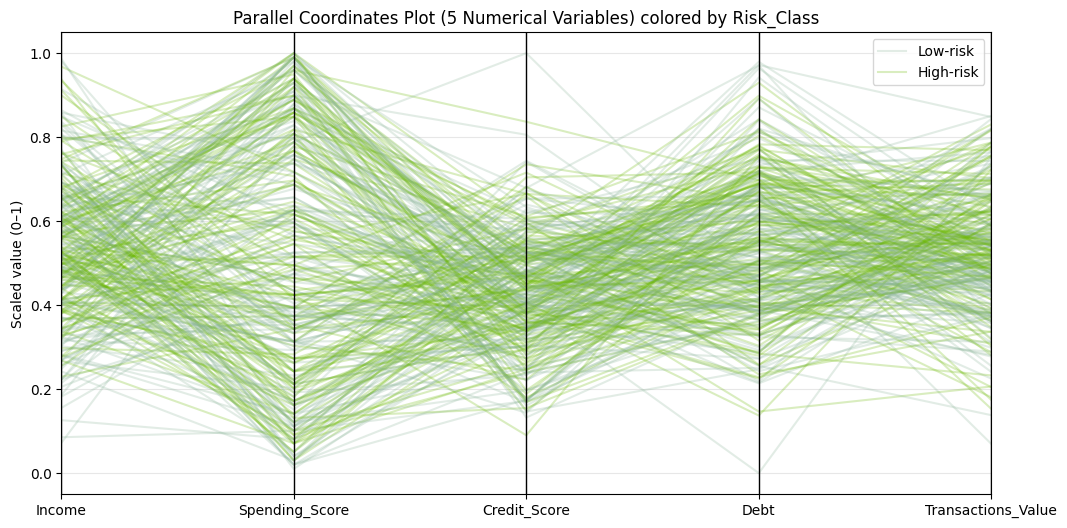

In [23]:
vars5 = [
    "Income",
    "Spending_Score",
    "Credit_Score",
    "Debt",
    "Transactions_Value"
]

pc_df = df[vars5 + ["Risk_Class"]].dropna().copy()

# Scale variables to [0,1] for better visualization
for col in vars5:
    pc_df[col] = (pc_df[col] - pc_df[col].min()) / (pc_df[col].max() - pc_df[col].min())

# Convert Risk_Class to readable labels
pc_df["Risk_Class"] = pc_df["Risk_Class"].map({0: "Low-risk", 1: "High-risk"})

# Optional: sample to reduce overplotting
pc_plot = pc_df.sample(n=min(300, len(pc_df)), random_state=42)

# Plot using pandas built-in plotting
plt.figure(figsize=(12,6))
pd.plotting.parallel_coordinates(
    pc_plot,
    class_column="Risk_Class",
    alpha=0.25
)

plt.title("Parallel Coordinates Plot (5 Numerical Variables) colored by Risk_Class")
plt.ylabel("Scaled value (0–1)")
plt.grid(True, alpha=0.3)
plt.show()

# 3(a) Standardize + Perform **PCA**

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove labels/targets if present (keep Dropout_Probability for PCR later, but NOT for PCA features)
for col in ["Risk_Class", "Market_Segment", "Region_Code", "Channel_Preference"]:
    if col in num_cols:
        num_cols.remove(col)

# Features for PCA (exclude Dropout_Probability from PCA features to avoid leakage into structure)
pca_features = [c for c in num_cols if c != "Dropout_Probability"]

# Drop missing
X = df[pca_features].dropna().copy()
y_risk = df.loc[X.index, "Risk_Class"]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA fit (all components first)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("PCA done. Shape of PCA scores:", X_pca.shape)

PCA done. Shape of PCA scores: (1000, 26)


# **3(b) Scree plot + components for ≥ 80% variance**

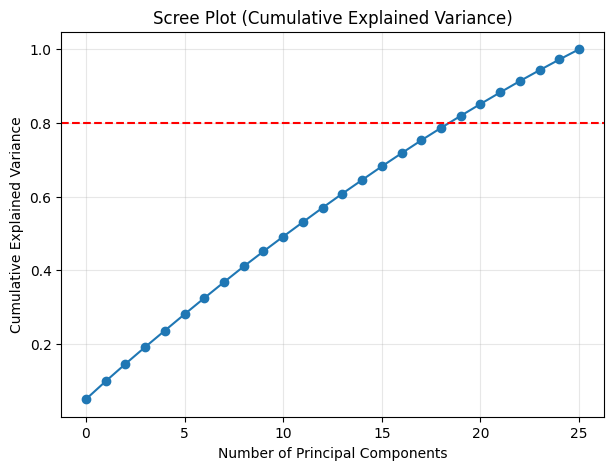

Number of PCs needed for ≥80% variance: 20
Cumulative variance at that point: 0.8193031513492909


In [25]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7,5))
plt.plot(cum_var, marker="o")
plt.axhline(0.80, linestyle="--", color="red")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot (Cumulative Explained Variance)")
plt.grid(True, alpha=0.3)
plt.show()

n_components_80 = np.argmax(cum_var >= 0.80) + 1
print("Number of PCs needed for ≥80% variance:", n_components_80)
print("Cumulative variance at that point:", cum_var[n_components_80-1])


# **3(c) PC1 vs PC2 plot colored by Risk_Class**

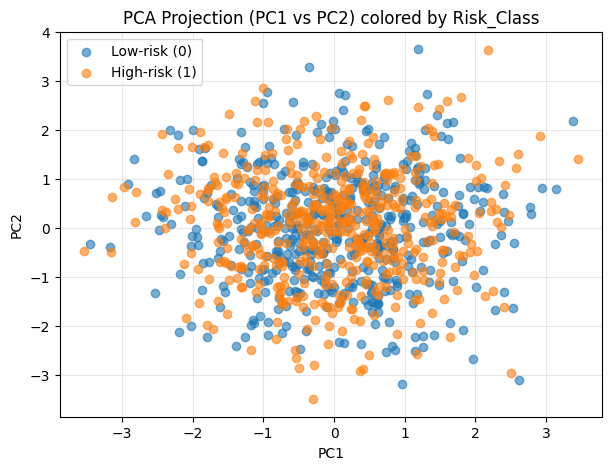

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca[y_risk == 0, 0], X_pca[y_risk == 0, 1], alpha=0.6, label="Low-risk (0)")
plt.scatter(X_pca[y_risk == 1, 0], X_pca[y_risk == 1, 1], alpha=0.6, label="High-risk (1)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2) colored by Risk_Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# **3(d) PCA loadings: variables contributing most to PC1**

Top + contributors to PC1:
Email_Open_Rate       0.371289
Ad_Clicks             0.370473
Discount_Usage        0.256108
Satisfaction_Score    0.225169
Social_Media_Usage    0.188592
Income                0.159881
Customer_Tenure       0.151754
Education_Years       0.149683
Hours_Online          0.109112
Product_Returns       0.094274
Name: PC1_Loading, dtype: float64

Top - contributors to PC1:
Spending_Score         -0.366525
Fraud_Risk_Score       -0.306059
Purchases_Month        -0.278113
Website_Visits         -0.221279
Debt                   -0.221063
Credit_Score           -0.140203
Transactions_Value     -0.117121
Channel _ Preference   -0.101964
Time_On_App            -0.072703
Loyalty_Points         -0.050829
Name: PC1_Loading, dtype: float64


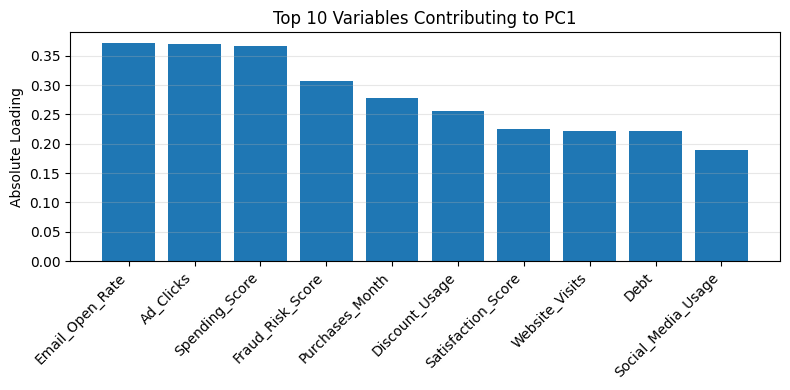

In [27]:
loadings = pd.Series(pca.components_[0], index=pca_features, name="PC1_Loading")

top_pos = loadings.sort_values(ascending=False).head(10)
top_neg = loadings.sort_values(ascending=True).head(10)

print("Top + contributors to PC1:")
print(top_pos)

print("\nTop - contributors to PC1:")
print(top_neg)

# Optional: bar plot of top absolute loadings
top_abs = loadings.abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
plt.bar(top_abs.index, top_abs.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute Loading")
plt.title("Top 10 Variables Contributing to PC1")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# **3(e) PCR to predict Dropout_Probability using selected PCs (≥80%)**

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Use the number of PCs that explain ≥80% variance
k = n_components_80

# Refit PCA with k components
pca_k = PCA(n_components=k)
X_k = pca_k.fit_transform(X_scaled)

# Target (aligned with X index)
y_drop = df.loc[X.index, "Dropout_Probability"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X_k, y_drop, test_size=0.2, random_state=42)

# Regression on PCs (PCR)
pcr = LinearRegression()
pcr.fit(X_train, y_train)

y_pred = pcr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("PCR using k =", k, "components")
print("R^2:", r2)
print("RMSE:", rmse)


PCR using k = 20 components
R^2: -0.07624320529020512
RMSE: 0.29713863365975735


# **4(a) Apply t-SNE and visualize the result**

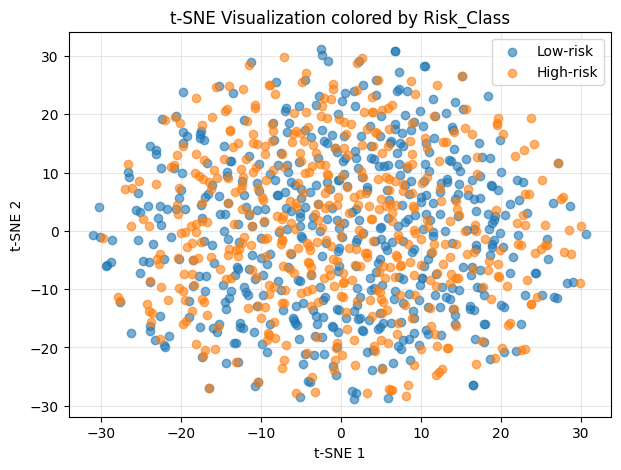

In [29]:
from sklearn.manifold import TSNE

num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in ["Risk_Class", "Market_Segment", "Region_Code", "Channel_Preference"]:
    if col in num_cols:
        num_cols.remove(col)

X = df[num_cols].dropna()
y = df.loc[X.index, "Risk_Class"]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], alpha=0.6, label="Low-risk")
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], alpha=0.6, label="High-risk")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization colored by Risk_Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **4(b) Apply UMAP and compare with t-SNE**

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


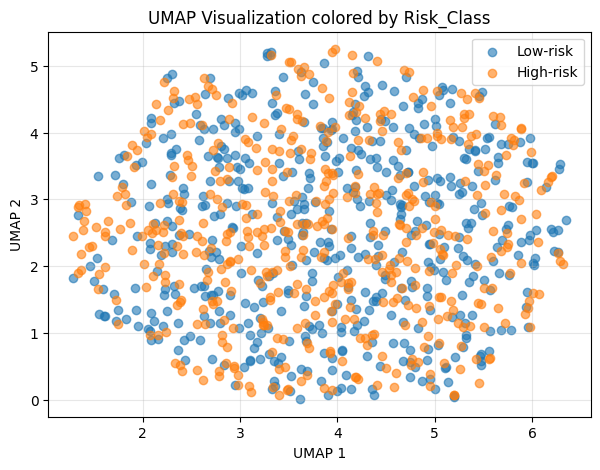

In [30]:
import umap.umap_ as umap

# UMAP
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X_umap[y==0, 0], X_umap[y==0, 1], alpha=0.6, label="Low-risk")
plt.scatter(X_umap[y==1, 0], X_umap[y==1, 1], alpha=0.6, label="High-risk")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Visualization colored by Risk_Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# **4(c) Comparison of PCA, t-SNE, and UMAP**

# **5(a) K-means clustering on PCA-reduced data**

Number of PCA components used: 21


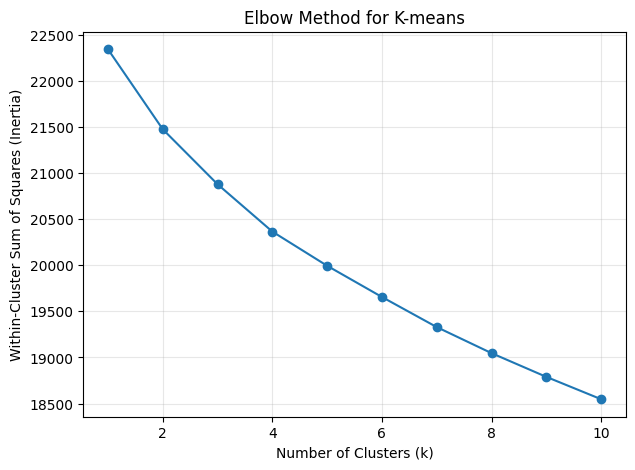

In [32]:
from sklearn.cluster import KMeans
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in ["Risk_Class", "Market_Segment", "Region_Code", "Channel_Preference"]:
    if col in num_cols:
        num_cols.remove(col)

X = df[num_cols].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (retain components explaining ≥80% variance)
pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
k_pca = np.argmax(cum_var >= 0.80) + 1

pca_k = PCA(n_components=k_pca)
X_pca = pca_k.fit_transform(X_scaled)

print("Number of PCA components used:", k_pca)



inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for K-means")
plt.grid(True, alpha=0.3)
plt.show()


# **5(b) Visualize clusters in PCA space and interpret**

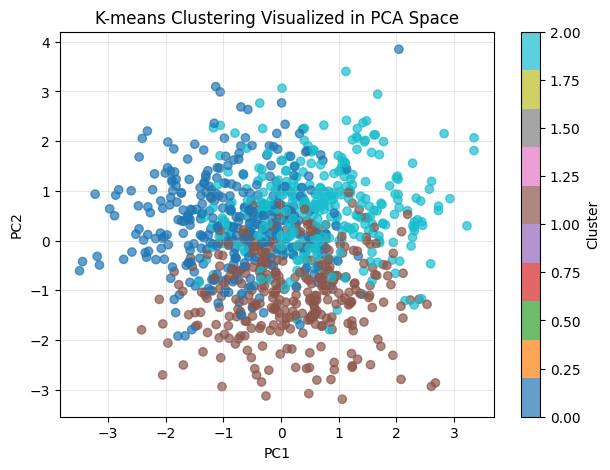

In [33]:
from sklearn.cluster import KMeans


k_opt = 3   # change this to the value you observe from elbow plot

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Plot clusters using first two PCs
plt.figure(figsize=(7,5))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters, cmap="tab10", alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clustering Visualized in PCA Space")
plt.colorbar(scatter, label="Cluster")
plt.grid(True, alpha=0.3)
plt.show()
